In [1]:
# Common imports
import numpy as np
import pandas as pd
from termcolor import colored
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = [10, 6]

print(colored('Imports loaded successfully ✓', 'green'))

Imports loaded successfully ✓


## 1. Data Loading

In [2]:
# Load preprocessed dataset
df_games = pd.read_csv('../data/games_preprocessed.csv')
df_games = df_games.dropna(subset=['description']).reset_index(drop=True)

print(colored(f'Documents loaded: {len(df_games)}', 'green'))
print(colored(f'Sample description (first 200 chars):', 'blue'))
print(df_games['description'].iloc[0][:200])

Documents loaded: 536
Sample description (first 200 chars):
✨Character.AI no es solo otra aplicación de conversación con IA: es un patio de recreo infinito para tu imaginación, creatividad y exploración. 

Sumérgete en conversaciones inmersivas, crea tus pro


## 2. BERT Embeddings with Sentence-Transformers

In [3]:
from sentence_transformers import SentenceTransformer

# Load multilingual model - works well with Spanish text
# paraphrase-multilingual-MiniLM-L12-v2 is fast and supports Spanish
model_name = 'paraphrase-multilingual-MiniLM-L12-v2'
print(colored(f'Loading model: {model_name}', 'blue'))

model = SentenceTransformer(model_name)
print(colored('Model loaded successfully ✓', 'green'))
print(colored(f'Embedding dimension: {model.get_sentence_embedding_dimension()}', 'blue'))

Loading model: paraphrase-multilingual-MiniLM-L12-v2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Model loaded successfully ✓
Embedding dimension: 384


## 3. Generate Document Embeddings

In [4]:
# Generate embeddings for all game descriptions
# Using original descriptions (not preprocessed) - BERT works better with full text
descriptions = df_games['description'].tolist()

print(colored(f'Generating embeddings for {len(descriptions)} documents...', 'blue'))
print(colored('This may take a few minutes...', 'blue'))

# Using original (non-preprocessed) descriptions for BERT:
# BERT's subword tokenizer handles punctuation, emojis and mixed language
# natively — preprocessing would remove useful contextual information
# batch_size=32: good balance between speed and memory on CPU
bert_vectors = model.encode(
    descriptions,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(colored(f'\nEmbeddings generated ✓', 'green'))
print(colored(f'Shape: {bert_vectors.shape}', 'green'))

Generating embeddings for 536 documents...
This may take a few minutes...


Batches:   0%|          | 0/17 [00:00<?, ?it/s]


Embeddings generated ✓
Shape: (536, 384)


In [5]:
# Save BERT vectors
import pickle

with open('../data/vectors_bert.pkl', 'wb') as f:
    pickle.dump(bert_vectors, f)

print(colored('BERT vectors saved to data/vectors_bert.pkl ✓', 'green'))
print(colored(f'Shape: {bert_vectors.shape}', 'blue'))
print(colored(f'Each document represented as a {bert_vectors.shape[1]}-dimensional vector', 'blue'))

BERT vectors saved to data/vectors_bert.pkl ✓
Shape: (536, 384)
Each document represented as a 384-dimensional vector


## 4. Analysis and Visualization

In [6]:
# Cosine similarity between documents
from sklearn.metrics.pairwise import cosine_similarity

def find_similar_games(title, top_n=5):
    matches = df_games[df_games['title'].str.contains(title, case=False, na=False)]
    if len(matches) == 0:
        print(colored(f'Title not found: {title}', 'red'))
        return
    idx = matches.index[0]
    similarities = cosine_similarity([bert_vectors[idx]], bert_vectors)[0]
    similar_indices = similarities.argsort()[::-1][1:top_n+1]
    
    print(colored(f'\nGames most similar to: {df_games["title"].iloc[idx]}', 'blue'))
    print(colored(f'Genre: {df_games["genre"].iloc[idx]}', 'blue'))
    for i in similar_indices:
        print(f'  {df_games["title"].iloc[i]:<45} | Genre: {df_games["genre"].iloc[i]:<20} | Similarity: {similarities[i]:.4f}')

# Test with games that exist in the dataset
find_similar_games('slither')
find_similar_games('Cookie Jam')
find_similar_games('Empire')


Games most similar to: slither.io
Genre: Acción
  Swipe Brick Breaker                           | Genre: Casuales             | Similarity: 0.6789
  Catch Up - Catch Up The Speed                 | Genre: Arcade               | Similarity: 0.6710
  King of Thieves                               | Genre: Estrategia           | Similarity: 0.6650
  Snake VS Block                                | Genre: Arcade               | Similarity: 0.6568
  Balatro                                       | Genre: Cartas               | Similarity: 0.6449

Games most similar to: Cookie Jam™ juego de combinar
Genre: Puzles
  Cookie Jam Blast™ Match 3                     | Genre: Puzles               | Similarity: 0.8119
  Dream Mania - Juegos Match 3                  | Genre: Puzles               | Similarity: 0.6408
  Candy Crush Friends Saga                      | Genre: Casuales             | Similarity: 0.6397
  Best Fiends - juego de match 3                | Genre: Casuales             | Similarity:

Computing t-SNE...


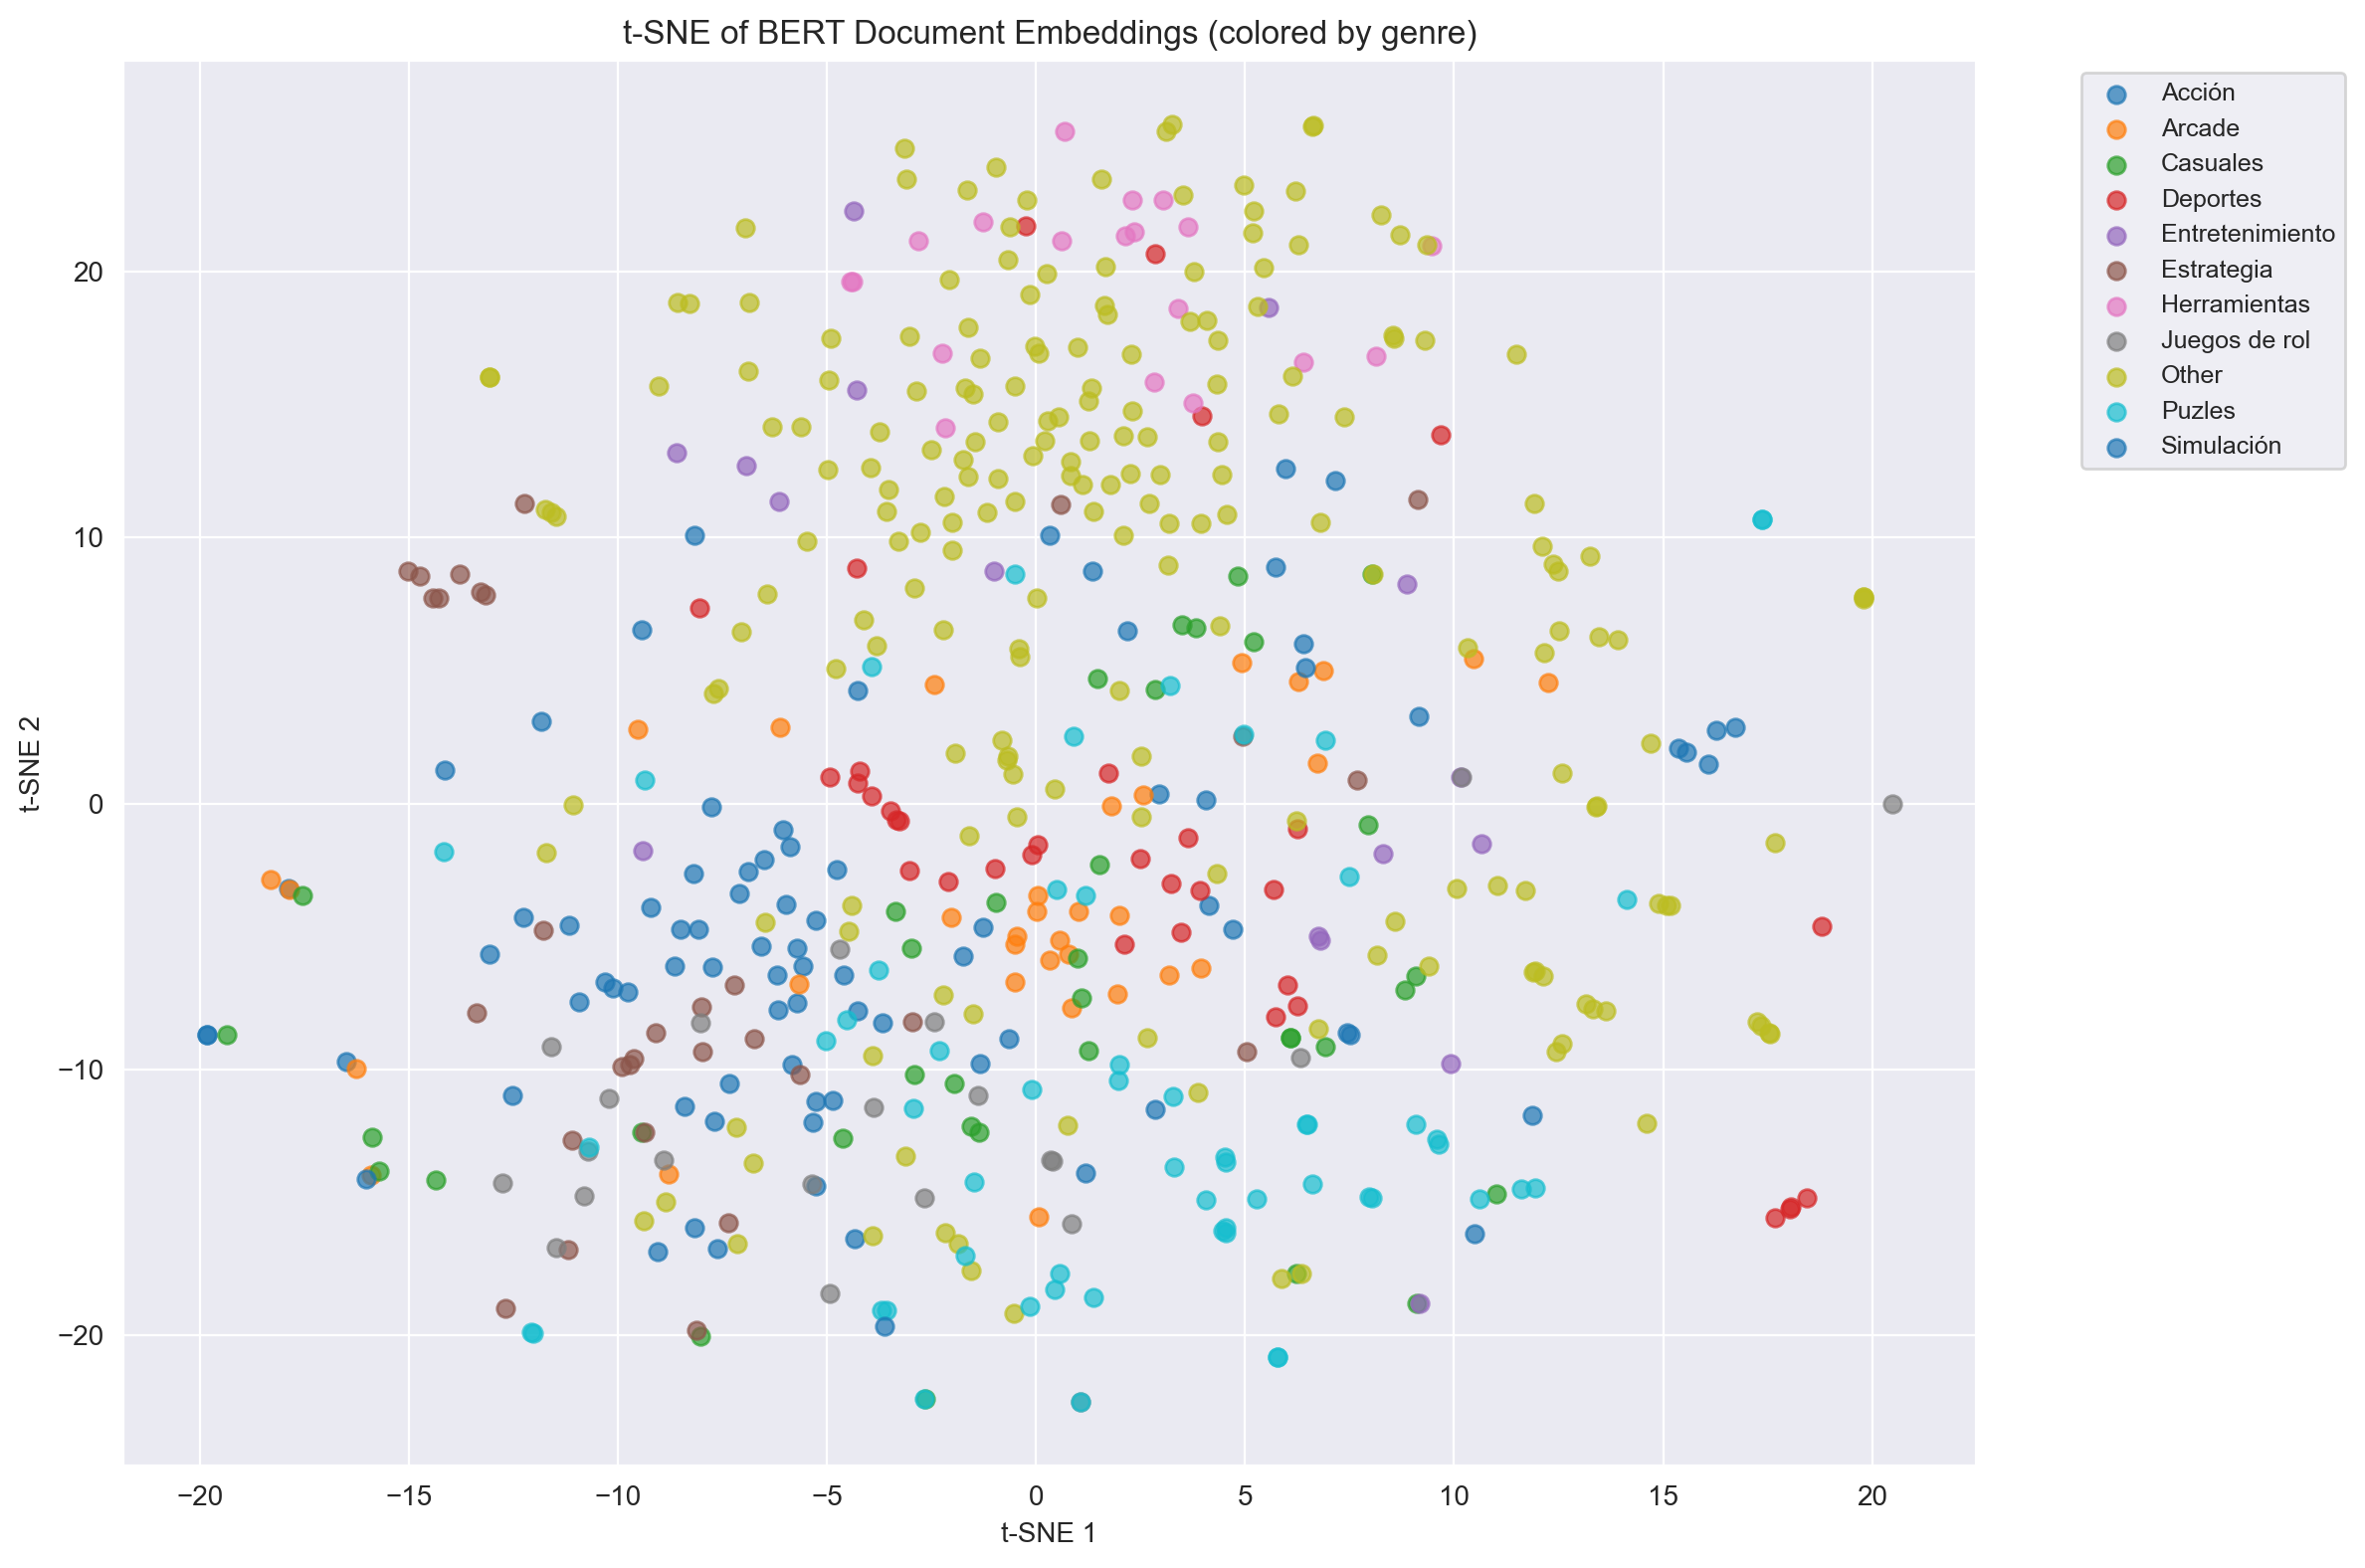

In [7]:
# t-SNE visualization colored by genre
from sklearn.manifold import TSNE

print(colored('Computing t-SNE...', 'blue'))
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
bert_vectors_2d = tsne.fit_transform(bert_vectors)

# Plot top 10 genres only for clarity
top_genres = df_games['genre'].value_counts().head(10).index
df_plot = df_games.copy()
df_plot['genre_plot'] = df_plot['genre'].apply(lambda x: x if x in top_genres else 'Other')

plt.figure(figsize=(12, 8))
palette = sns.color_palette('tab10', 11)
genres_plot = df_plot['genre_plot'].unique()

for i, genre in enumerate(sorted(genres_plot)):
    mask = df_plot['genre_plot'] == genre
    plt.scatter(bert_vectors_2d[mask, 0], bert_vectors_2d[mask, 1],
                label=genre, alpha=0.7, s=40)

plt.title('t-SNE of BERT Document Embeddings (colored by genre)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

============= Similarity Analysis =============
Avg within-genre similarity:  0.3706
Avg across-genre similarity:  0.2446


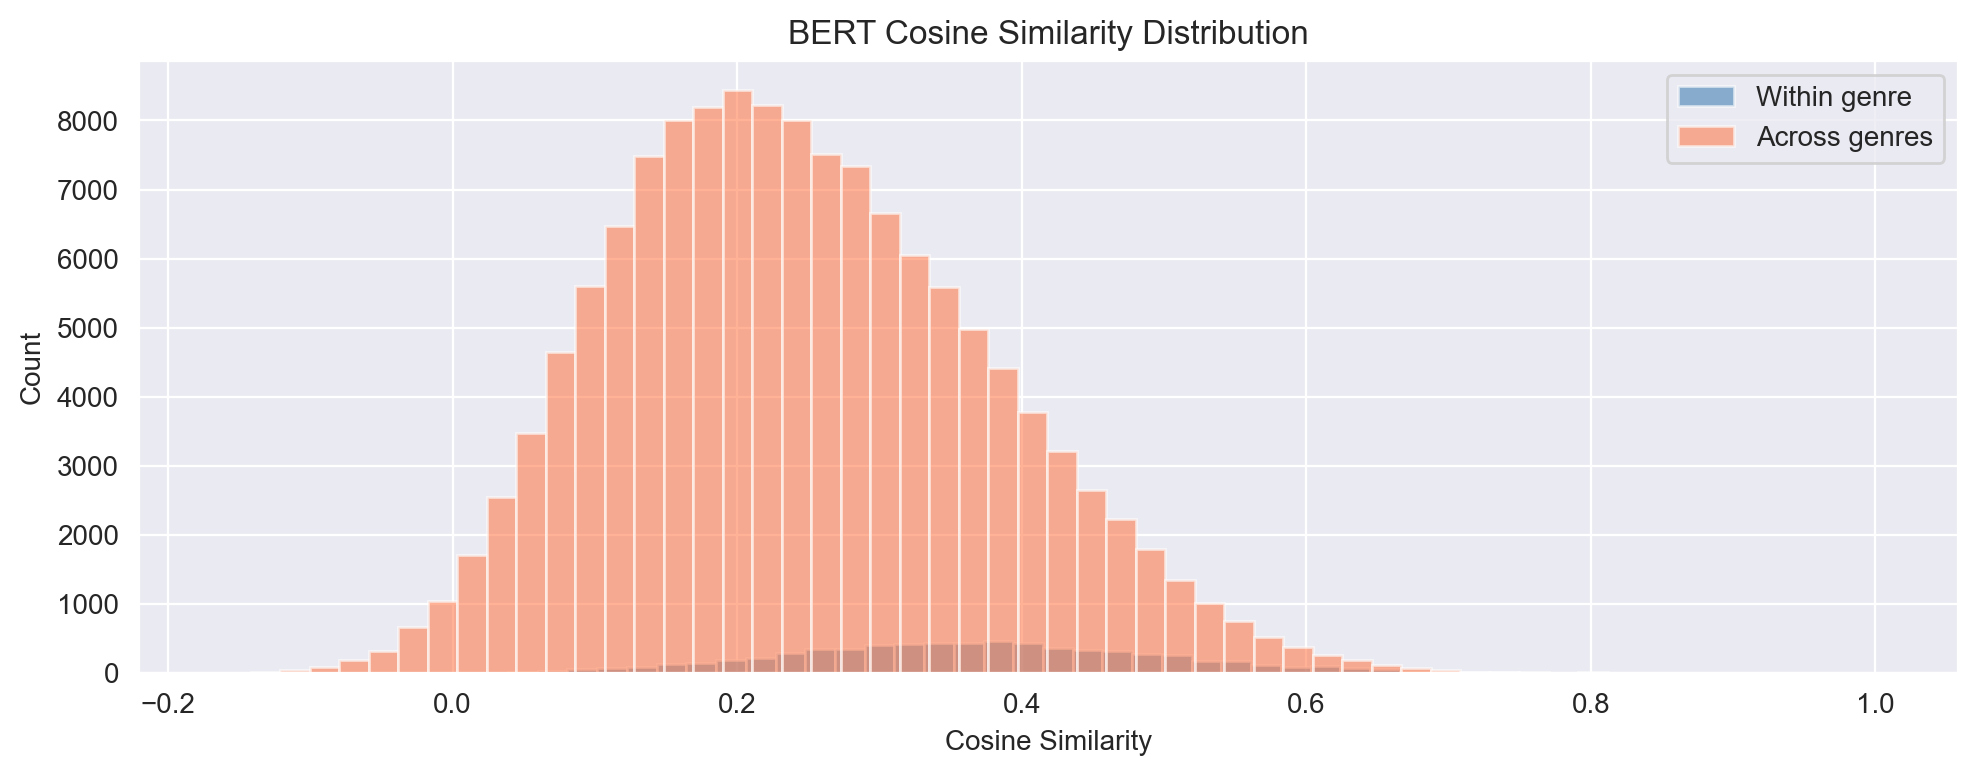

In [8]:
# Compare average similarity within genre vs across genres
sim_matrix = cosine_similarity(bert_vectors)

within_genre_sims = []
across_genre_sims = []

genres = df_games['genre'].values
for i in range(len(df_games)):
    for j in range(i+1, len(df_games)):
        if genres[i] == genres[j]:
            within_genre_sims.append(sim_matrix[i, j])
        else:
            across_genre_sims.append(sim_matrix[i, j])

print(colored('============= Similarity Analysis =============', 'blue'))
print(colored(f'Avg within-genre similarity:  {np.mean(within_genre_sims):.4f}', 'green'))
print(colored(f'Avg across-genre similarity:  {np.mean(across_genre_sims):.4f}', 'green'))

plt.figure(figsize=(10, 4))
plt.hist(within_genre_sims, bins=50, alpha=0.6, label='Within genre', color='steelblue')
plt.hist(across_genre_sims, bins=50, alpha=0.6, label='Across genres', color='coral')
plt.title('BERT Cosine Similarity Distribution')
plt.xlabel('Cosine Similarity')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Summary

In [9]:
print(colored('============= BERT Embeddings Summary =============', 'blue'))
print(colored(f'Model:                    {model_name}', 'green'))
print(colored(f'Documents embedded:       {bert_vectors.shape[0]}', 'green'))
print(colored(f'Embedding dimension:      {bert_vectors.shape[1]}', 'green'))
print(colored(f'Avg within-genre sim:     {np.mean(within_genre_sims):.4f}', 'green'))
print(colored(f'Avg across-genre sim:     {np.mean(across_genre_sims):.4f}', 'green'))
print(colored(f'Saved to:                 data/vectors_bert.pkl', 'green'))
print(colored('\nKey observations:', 'blue'))
print('  - Within-genre similarity significantly higher than across-genre')
print('  - Model captures semantic relationships: similar games cluster together')
print('  - Multilingual model handles Spanish descriptions effectively')
print('  - Sentence-level embeddings capture full description context')

============= BERT Embeddings Summary =============
Model:                    paraphrase-multilingual-MiniLM-L12-v2
Documents embedded:       536
Embedding dimension:      384
Avg within-genre sim:     0.3706
Avg across-genre sim:     0.2446
Saved to:                 data/vectors_bert.pkl

Key observations:
  - Within-genre similarity significantly higher than across-genre
  - Model captures semantic relationships: similar games cluster together
  - Multilingual model handles Spanish descriptions effectively
  - Sentence-level embeddings capture full description context
